In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.shape

(768, 9)

In [ ]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Replace invalid zero values with NaN
invalid_columns = [ 'glucose_concentration', 'diastolic_blood_pressure', 'triceps_sf_thickness', 'serum_insulin', 'bmi' ]


In [ ]:
#SELECT TARGET AND PREDICTOR VARIABLES
# Target variable:
# BMI - continuous variable that we want to predict

# Predictor variables:
# Glucose, BloodPressure, SkinThickness,
# Insulin, DiabetesPedigreeFunction and Age

X = df[
    [
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "DiabetesPedigreeFunction",
        "Age"
    ]
]

y = df["BMI"]

print("\nPredictor Variables:")
print(X.head())

print("\nTarget Variable (BMI):")
print(y.head())


Predictor Variables:
   Glucose  BloodPressure  SkinThickness  Insulin  DiabetesPedigreeFunction  \
0      148             72             35        0                     0.627   
1       85             66             29        0                     0.351   
2      183             64              0        0                     0.672   
3       89             66             23       94                     0.167   
4      137             40             35      168                     2.288   

   Age  
0   50  
1   31  
2   32  
3   21  
4   33  

Target Variable (BMI):
0    33.6
1    26.6
2    23.3
3    28.1
4    43.1
Name: BMI, dtype: float64


In [ ]:
# CHECK FOR MISSING AND INVALID VALUES
print("\nMissing Values:")
print(df.isnull().sum())


# In the Pima dataset, zero values in the following medical
# attributes can represent missing/invalid measurements.

invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("\nNumber of zero values in selected columns:")

for column in invalid_columns:
    print(column, ":", (df[column] == 0).sum())


Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Number of zero values in selected columns:
Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [ ]:
#REPLACE INVALID ZERO VALUES WITH NaN
df[invalid_columns] = df[invalid_columns].replace(0, np.nan)

print("\nMissing values after replacing invalid zeros:")
print(df[invalid_columns].isnull().sum())


Missing values after replacing invalid zeros:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [ ]:
#HANDLE MISSING VALUES
# Fill missing values using the median of each column

for column in invalid_columns:
    df[column] = df[column].fillna(df[column].median())

print("\nMissing values after median imputation:")
print(df[invalid_columns].isnull().sum())


Missing values after median imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [ ]:
# SELECT X AND y AFTER PREPROCESSING
X = df[
    [
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "DiabetesPedigreeFunction",
        "Age"
    ]
]

y = df["BMI"]

In [ ]:
#DIVIDE DATA INTO TRAINING AND TESTING SETS
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Size:")
print(X_train.shape)

print("\nTesting Data Size:")
print(X_test.shape)

print("\nTraining Target Size:")
print(y_train.shape)

print("\nTesting Target Size:")
print(y_test.shape)


Training Data Size:
(614, 6)

Testing Data Size:
(154, 6)

Training Target Size:
(614,)

Testing Target Size:
(154,)


In [ ]:
#DEVELOP A LINEAR REGRESSION MODEL
model = LinearRegression()
model.fit(X_train, y_train)
for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

print("\nIntercept:", model.intercept_)
y_pred = model.predict(X_test)

print("\nFirst 10 Actual BMI Values:")
print(y_test.head(10).values)

print("\nFirst 10 Predicted BMI Values:")
print(y_pred[:10])

Glucose : 0.029545705883975815
BloodPressure : 0.10878723614477985
SkinThickness : 0.4242382943694571
Insulin : 0.003972055958186921
DiabetesPedigreeFunction : 1.6290124373166386
Age : -0.09010385939218434

Intercept: 10.357253065742135

First 10 Actual BMI Values:
[34.  35.7 30.8 24.6 29.9 37.7 20.4 33.8 31.3 33.7]

First 10 Predicted BMI Values:
[31.14295568 34.24646004 31.67519286 33.35194345 32.80263749 31.13554559
 24.15883718 31.99986897 32.76012577 30.48366763]


In [ ]:

comparison = pd.DataFrame({
    "Actual BMI": y_test.values,
    "Predicted BMI": y_pred
})

print("\nActual vs Predicted BMI:")
print(comparison.head(10))


Actual vs Predicted BMI:
   Actual BMI  Predicted BMI
0        34.0      31.142956
1        35.7      34.246460
2        30.8      31.675193
3        24.6      33.351943
4        29.9      32.802637
5        37.7      31.135546
6        20.4      24.158837
7        33.8      31.999869
8        31.3      32.760126
9        33.7      30.483668


In [ ]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("REGRESSION MODEL PERFORMANCE")

print("Mean Absolute Error (MAE):", mae)

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

print("R² Score:", r2)

REGRESSION MODEL PERFORMANCE
Mean Absolute Error (MAE): 4.386600543235652
Mean Squared Error (MSE): 34.77864534559686
Root Mean Squared Error (RMSE): 5.8973422272746605
R² Score: 0.204832236876332


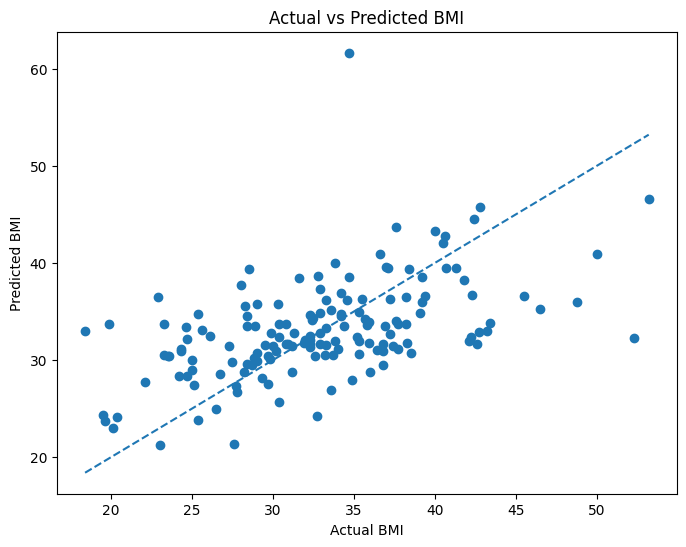

In [ ]:
#ACTUAL VS PREDICTED VALUES PLOT
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs Predicted BMI")

plt.show()

In [ ]:
#RESIDUAL CALCULATION
residuals = y_test - y_pred

print("\nFirst 10 Residuals:")
print(residuals.head(10).values)


First 10 Residuals:
[ 2.85704432  1.45353996 -0.87519286 -8.75194345 -2.90263749  6.56445441
 -3.75883718  1.80013103 -1.46012577  3.21633237]


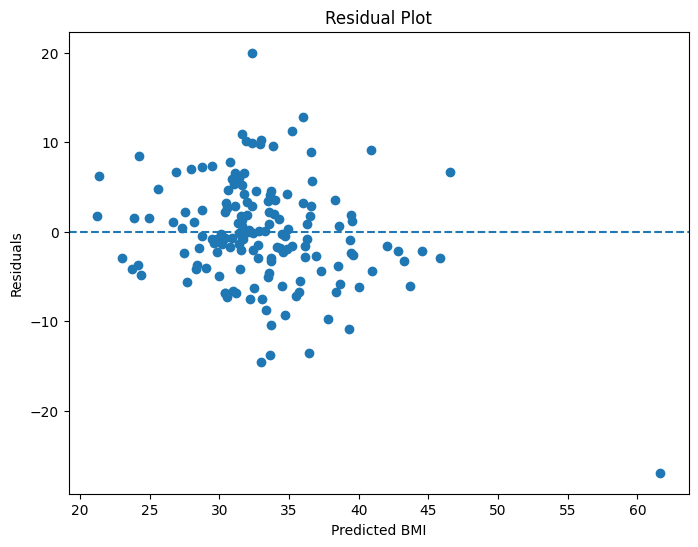

In [ ]:
#RESIDUAL PLOT
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted BMI")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

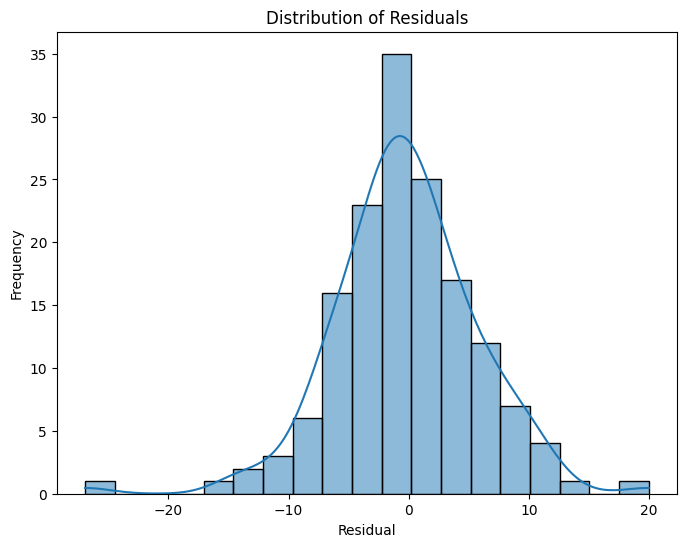

In [ ]:
#DISTRIBUTION OF RESIDUALS
plt.figure(figsize=(8, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

In [ ]:
# RESIDUAL STATISTICS
print("\n--- Residual Analysis ---")

print("Mean Residual:", residuals.mean())

print("Minimum Residual:", residuals.min())

print("Maximum Residual:", residuals.max())

print("Standard Deviation of Residuals:",
      residuals.std())


--- Residual Analysis ---
Mean Residual: -0.2607791145398794
Minimum Residual: -26.939204661511212
Maximum Residual: 19.984563292927717
Standard Deviation of Residuals: 5.910795760682347


In [ ]:
# FINAL RESULT
print("FINAL RESULT")
print("Target Variable: BMI")
print("Regression Model: Linear Regression")
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R² Score:", round(r2, 3))

FINAL RESULT
Target Variable: BMI
Regression Model: Linear Regression
MAE: 4.387
MSE: 34.779
RMSE: 5.897
R² Score: 0.205
